<a href="https://colab.research.google.com/github/manishasubramani07/Ml-project-1/blob/main/houseprices_GitHub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("houseprices.csv")
print(df.head())

   area  bedroom  bathroom  age  location    price
0   650        1         1   20         4  1800000
1   720        2         1   15         5  2000000
2   900        2         2   12         6  2500000
3  1000        3         2   10         7  3000000
4  1200        3         3   10         6  3500000


In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   area      10 non-null     int64
 1   bedroom   10 non-null     int64
 2   bathroom  10 non-null     int64
 3   age       10 non-null     int64
 4   location  10 non-null     int64
 5   price     10 non-null     int64
dtypes: int64(6)
memory usage: 608.0 bytes
None
             area    bedroom   bathroom        age   location         price
count    10.00000  10.000000  10.000000  10.000000  10.000000  1.000000e+01
mean   1527.00000   3.900000   3.700000   9.300000   5.400000  4.280000e+06
std     734.36367   2.024846   2.213594   5.250397   0.966092  2.148798e+06
min     650.00000   1.000000   1.000000   3.000000   4.000000  1.800000e+06
25%     925.00000   2.250000   2.000000   5.250000   5.000000  2.625000e+06
50%    1400.00000   3.500000   3.500000   8.500000   5.500000  3.750000e+06
75%    2075.00000   5.7

In [ ]:
df.dropna()
df.fillna(df.mean())
df.fillna(method='ffill')

,area,bedroom,bathroom,age,location,price
0,650,1,1,20,4,1800000
1,720,2,1,15,5,2000000
2,900,2,2,12,6,2500000
3,1000,3,2,10,7,3000000
4,1200,3,3,10,6,3500000
5,1600,4,4,5,6,4000000
6,2000,5,5,3,5,5000000
7,2100,6,6,5,4,6000000
8,2500,6,6,6,6,7000000
9,2600,7,7,7,5,8000000


In [ ]:
x=df[["area","bedroom","bathroom","age","location","price"]]
y=df["price"]
print(x.shape)
print(y.shape)

(10, 6)
(10,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)
print("Train size:",x_train.shape[0])
print("Test size:",x_test.shape[0])

Train size: 8
Test size: 2


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print("Coefficients:",model.coef_)
print("Intercept:",model.intercept_)

Coefficients: [3.20068047e-12 6.77648493e-10 5.94821508e-10 2.36584803e-10
 3.51690503e-10 1.00000000e+00]
Intercept: -4.6566128730773926e-09


In [ ]:
y_pred=model.predict(x_test)
print(y_pred [0:5])
print(y_test.values[:5])

[7000000. 2000000.]
[7000000 2000000]


In [ ]:
from sklearn.metrics import(
mean_absolute_error,mean_squared_error,r2_score)
import numpy as np
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:",mae,"MSE:",mse,"RMSE:",rmse,"R2:",r2)

MAE: 6.984919309616089e-10 MSE: 5.421010862427522e-19 RMSE: 7.362751430292566e-10 R2: 1.0


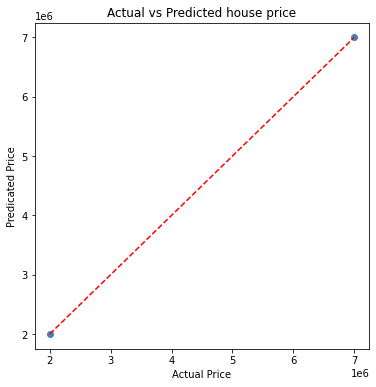

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred,color="steelblue")
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],"r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicated Price")
plt.title("Actual vs Predicted house price")
plt.show()

In [ ]:
x2=df[["area","bedroom","bathroom","age","location"]]
y2=df["price"]
x2_train,x2_test,y2_train,y2_test=train_test_split(
    x2,y2,test_size=0.2,random_state=42
)
model2=LinearRegression()
model2.fit(x2_train,y2_train)
pred2=model2.predict(x2_test)
print("R2(3 features):",r2_score(y2_test,pred2))
print("R2(5 features):",r2)


R2(3 features): 0.9991332126107083
R2(5 features): 1.0
